In [1]:
!pip install roboflow ultralytics easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 29.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
print("YOLOv8s pretrained classes:")
for k, v in model.names.items():
    print(f"  {k}: {v}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8s pretrained classes:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sand

Results saved to /content/runs/detect/predict


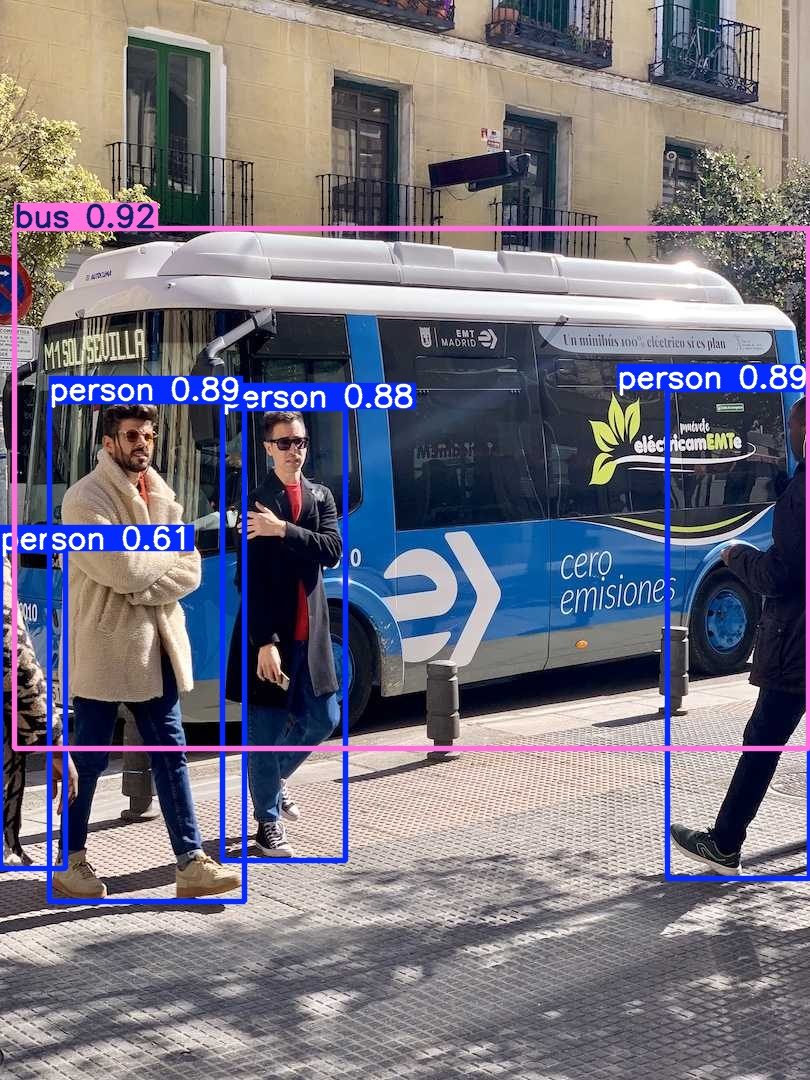

  Detected: bus | Confidence: 0.92
  Detected: person | Confidence: 0.89
  Detected: person | Confidence: 0.89
  Detected: person | Confidence: 0.88
  Detected: person | Confidence: 0.61


In [4]:
!wget -q "https://ultralytics.com/images/bus.jpg" -O traffic_test.jpg

results = model.predict(source="traffic_test.jpg", conf=0.3, save=True, verbose=False)

from IPython.display import Image as IPImage, display
display(IPImage("runs/detect/predict/traffic_test.jpg"))

for r in results:
    for box in r.boxes:
        label = model.names[int(box.cls)]
        conf = float(box.conf)
        print(f"  Detected: {label} | Confidence: {conf:.2f}")

In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key="WjeGVo4duw0yWW8lEsXr")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(13)
dataset = version.download("yolov8")

print("Dataset path:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-13 in yolov8:: 100%|██████████| 203744/203744 [00:35<00:00, 5751.12it/s]


Dataset path: /content/License-Plate-Recognition-13


In [6]:
plate_model = YOLO("yolov8s.pt")

plate_model.train(
    data="/content/License-Plate-Recognition-13/data.yaml",
    epochs=3,
    imgsz=640,
    batch=16,
    name="plate_detector"
)

print("Training done!")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-13/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [7]:
import shutil, os

# Save model
shutil.copy(
    "runs/detect/plate_detector/weights/best.pt",
    "/content/drive/MyDrive/plate_detector.pt"
)

# Save entire runs folder to Drive
shutil.copytree(
    "runs/detect/plate_detector",
    "/content/drive/MyDrive/plate_detector_runs",
    dirs_exist_ok=True
)

print("Model and graphs saved to Drive!")

Model and graphs saved to Drive!



--- results.png ---


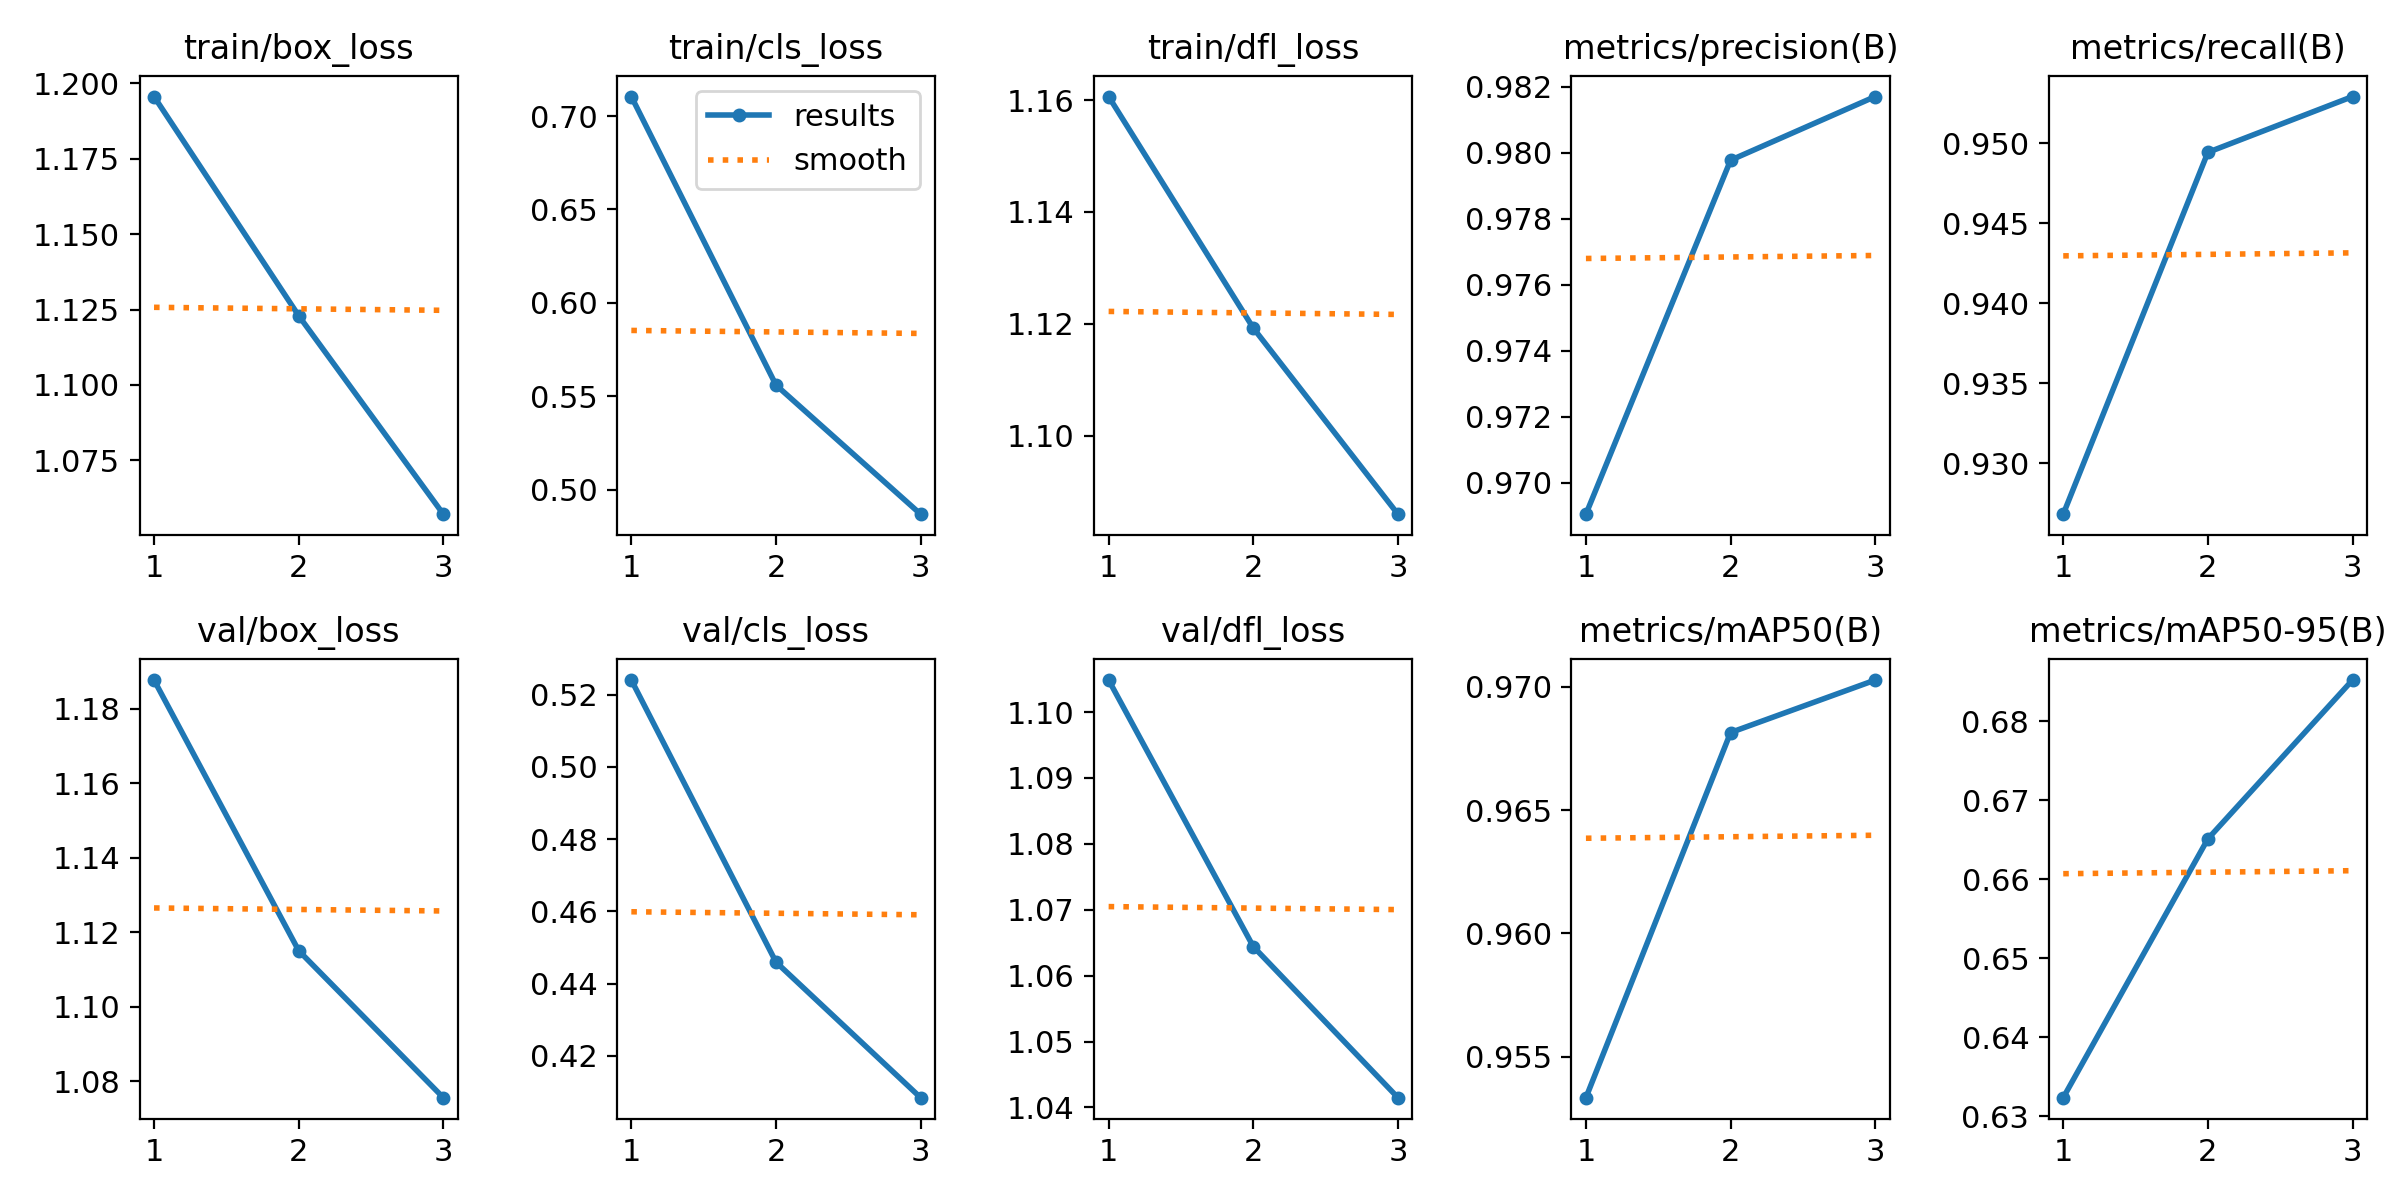


--- confusion_matrix.png ---


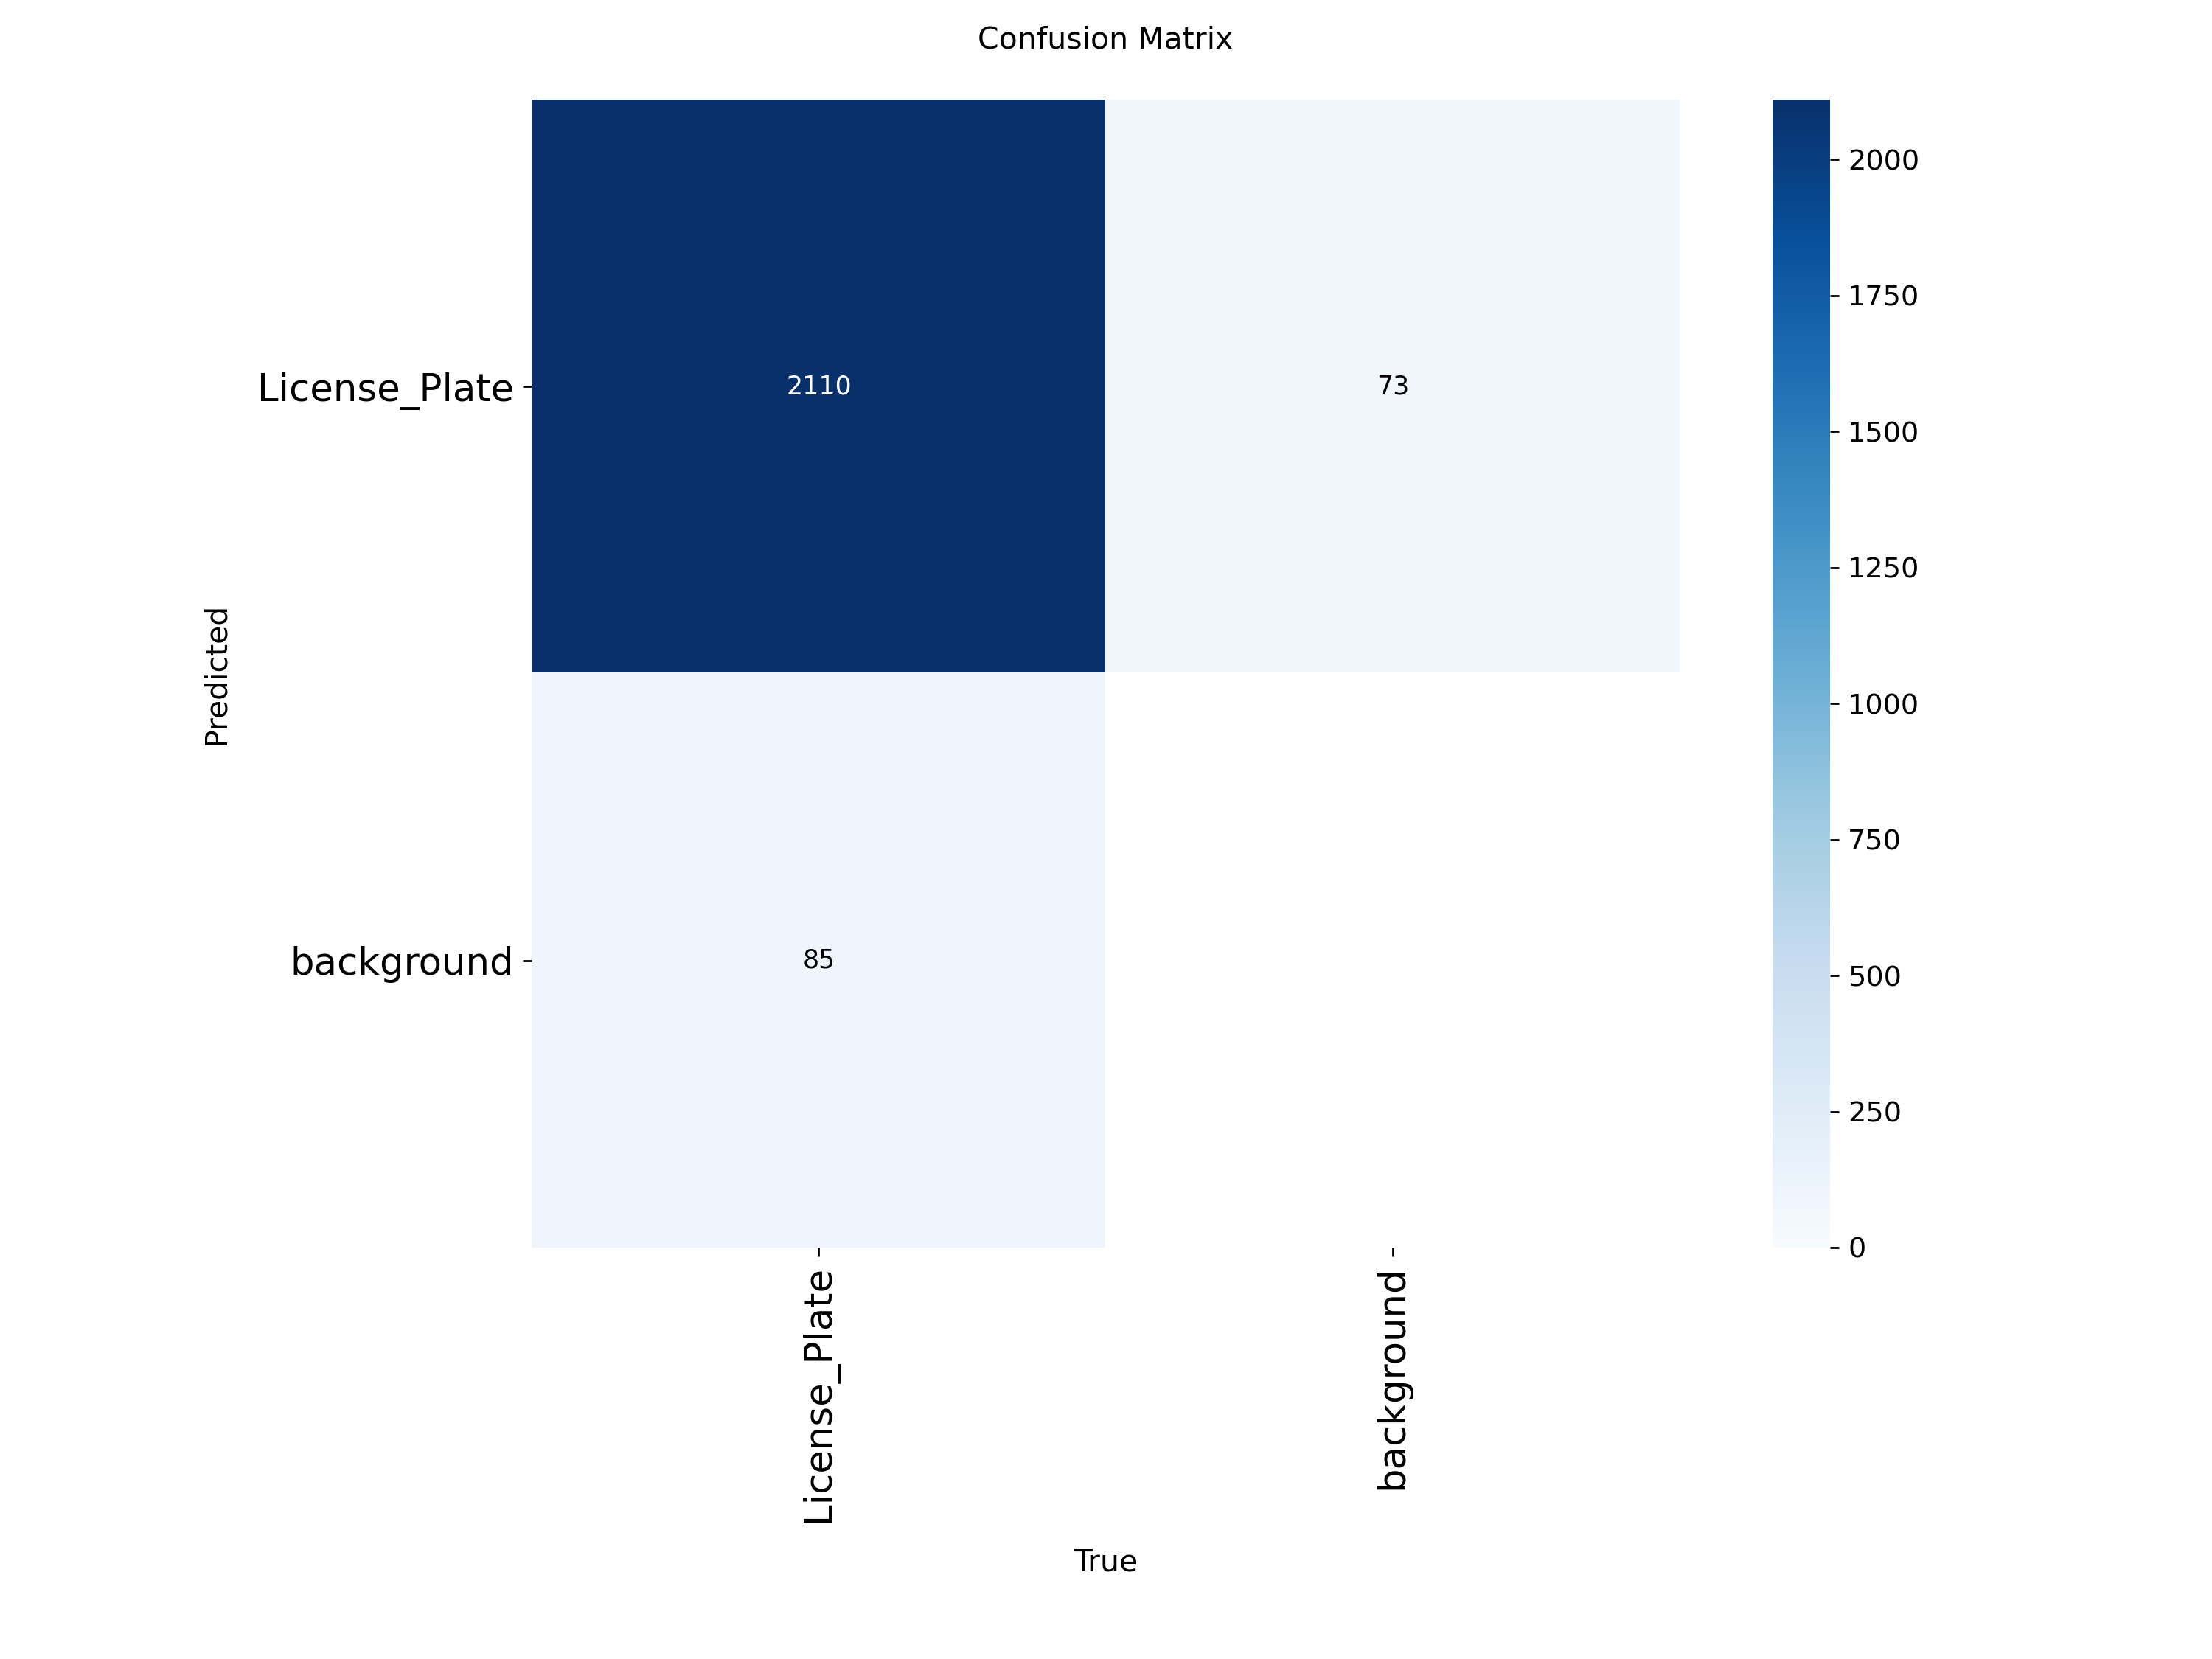


--- BoxPR_curve.png ---


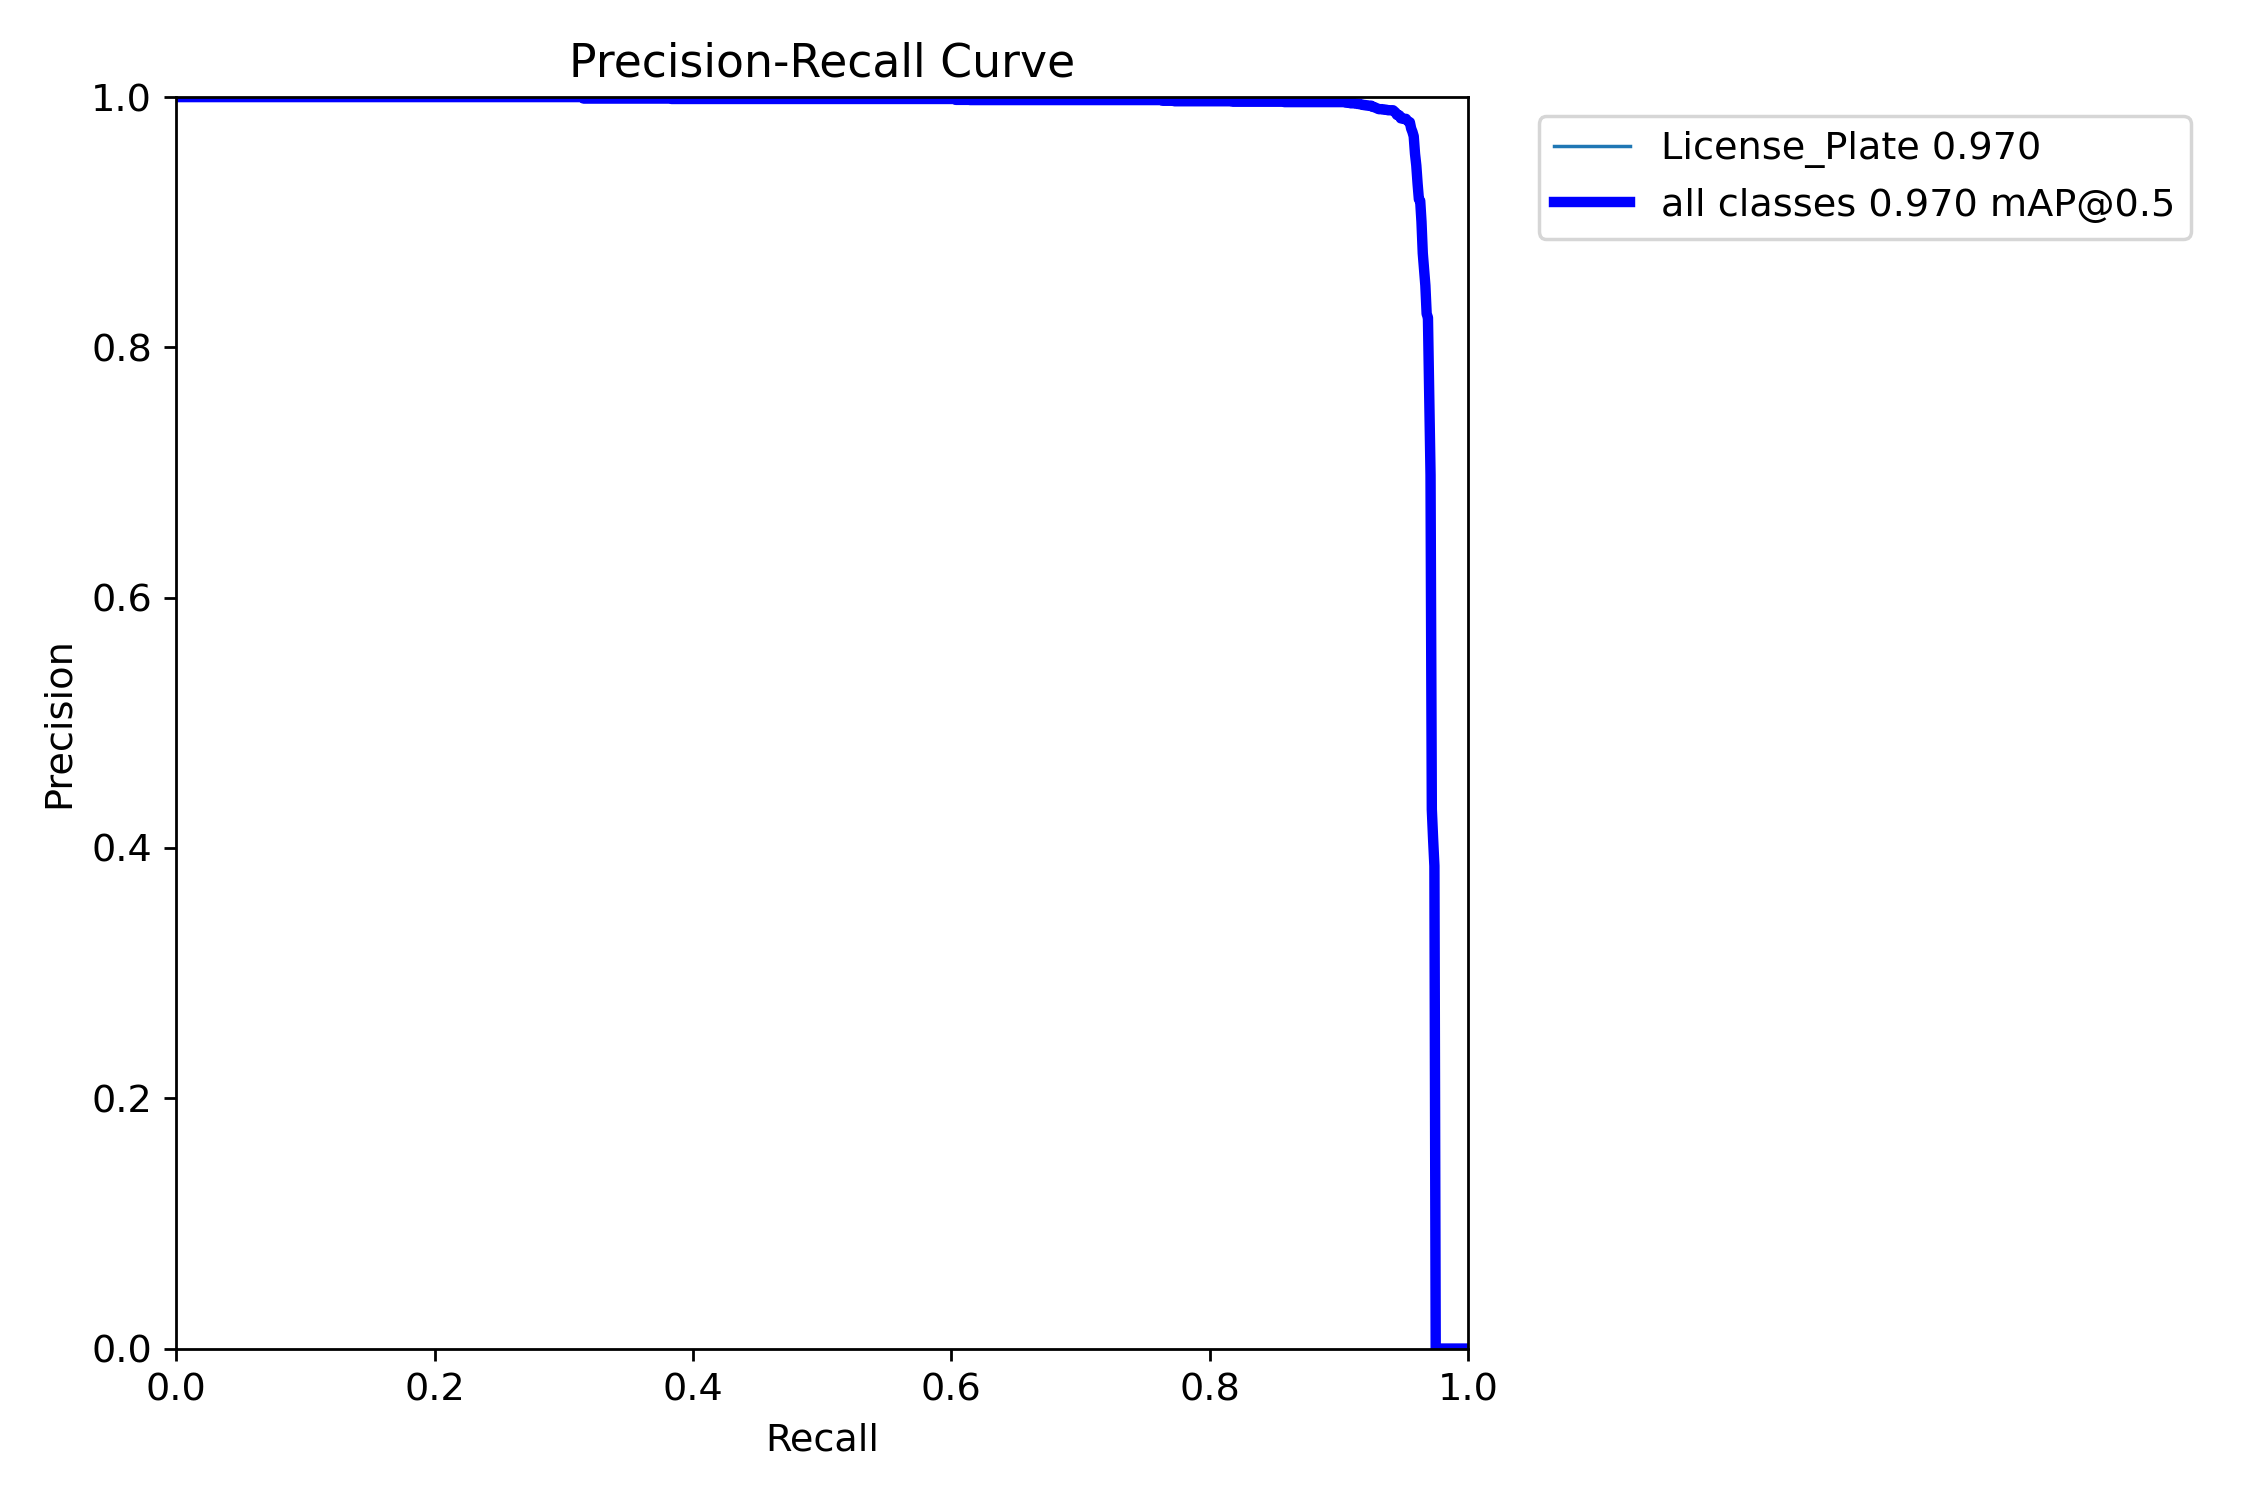


--- BoxF1_curve.png ---


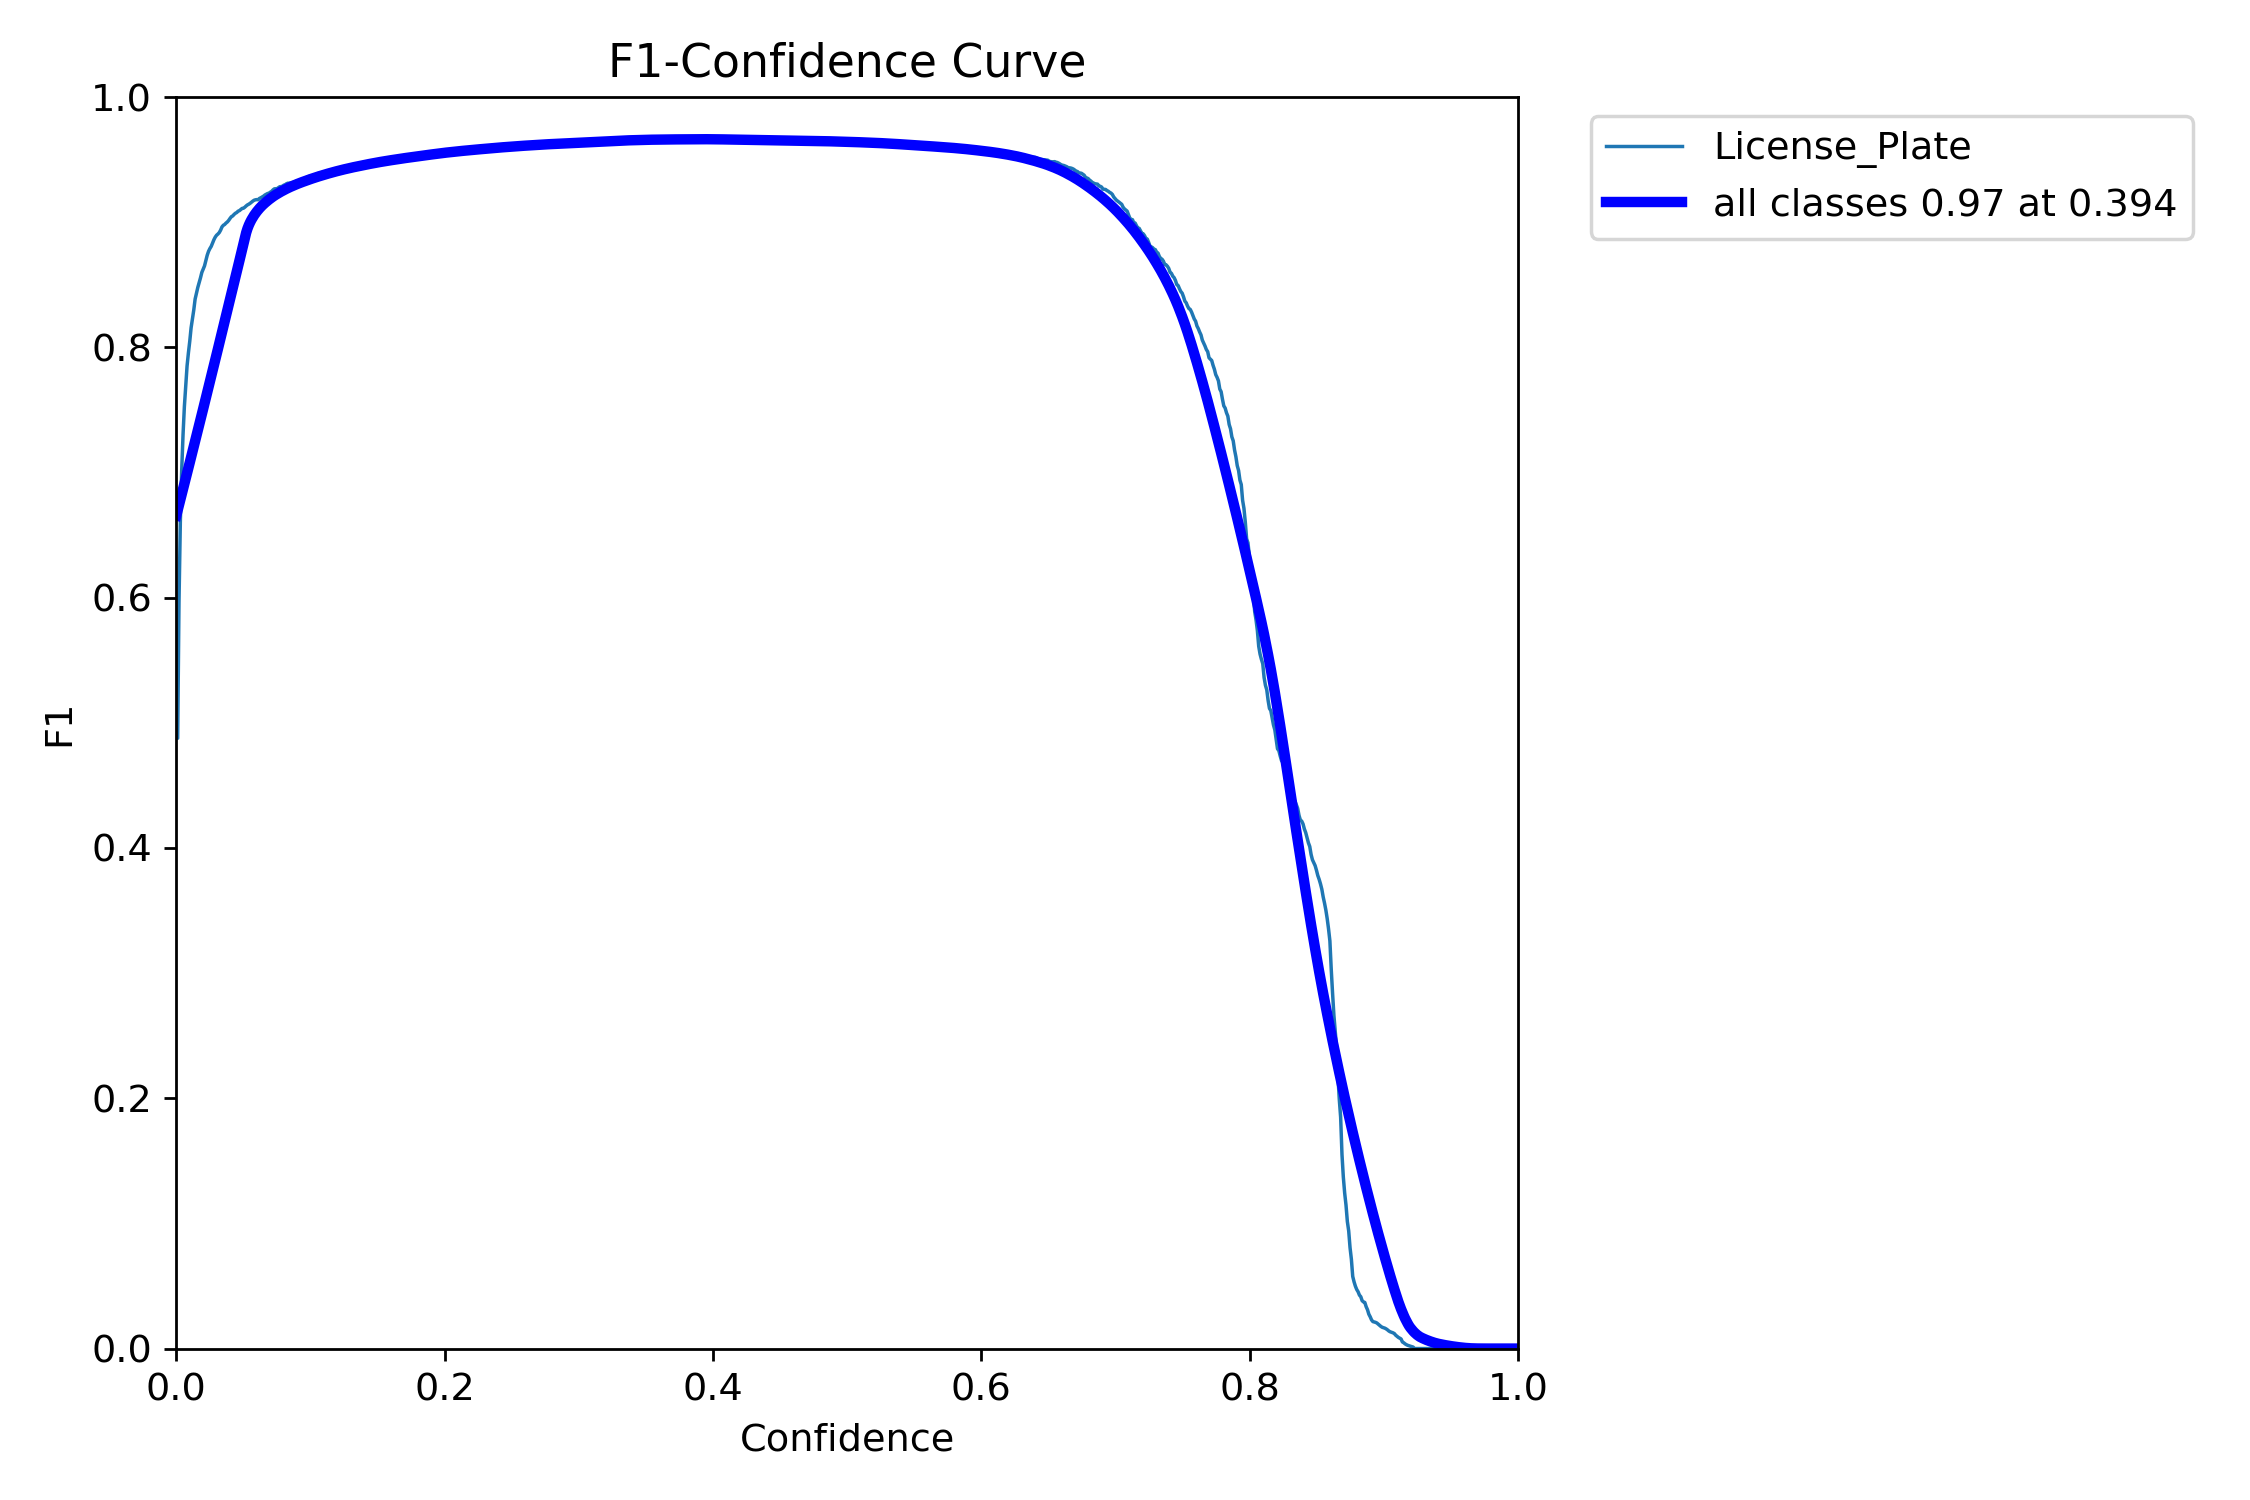


--- BoxP_curve.png ---


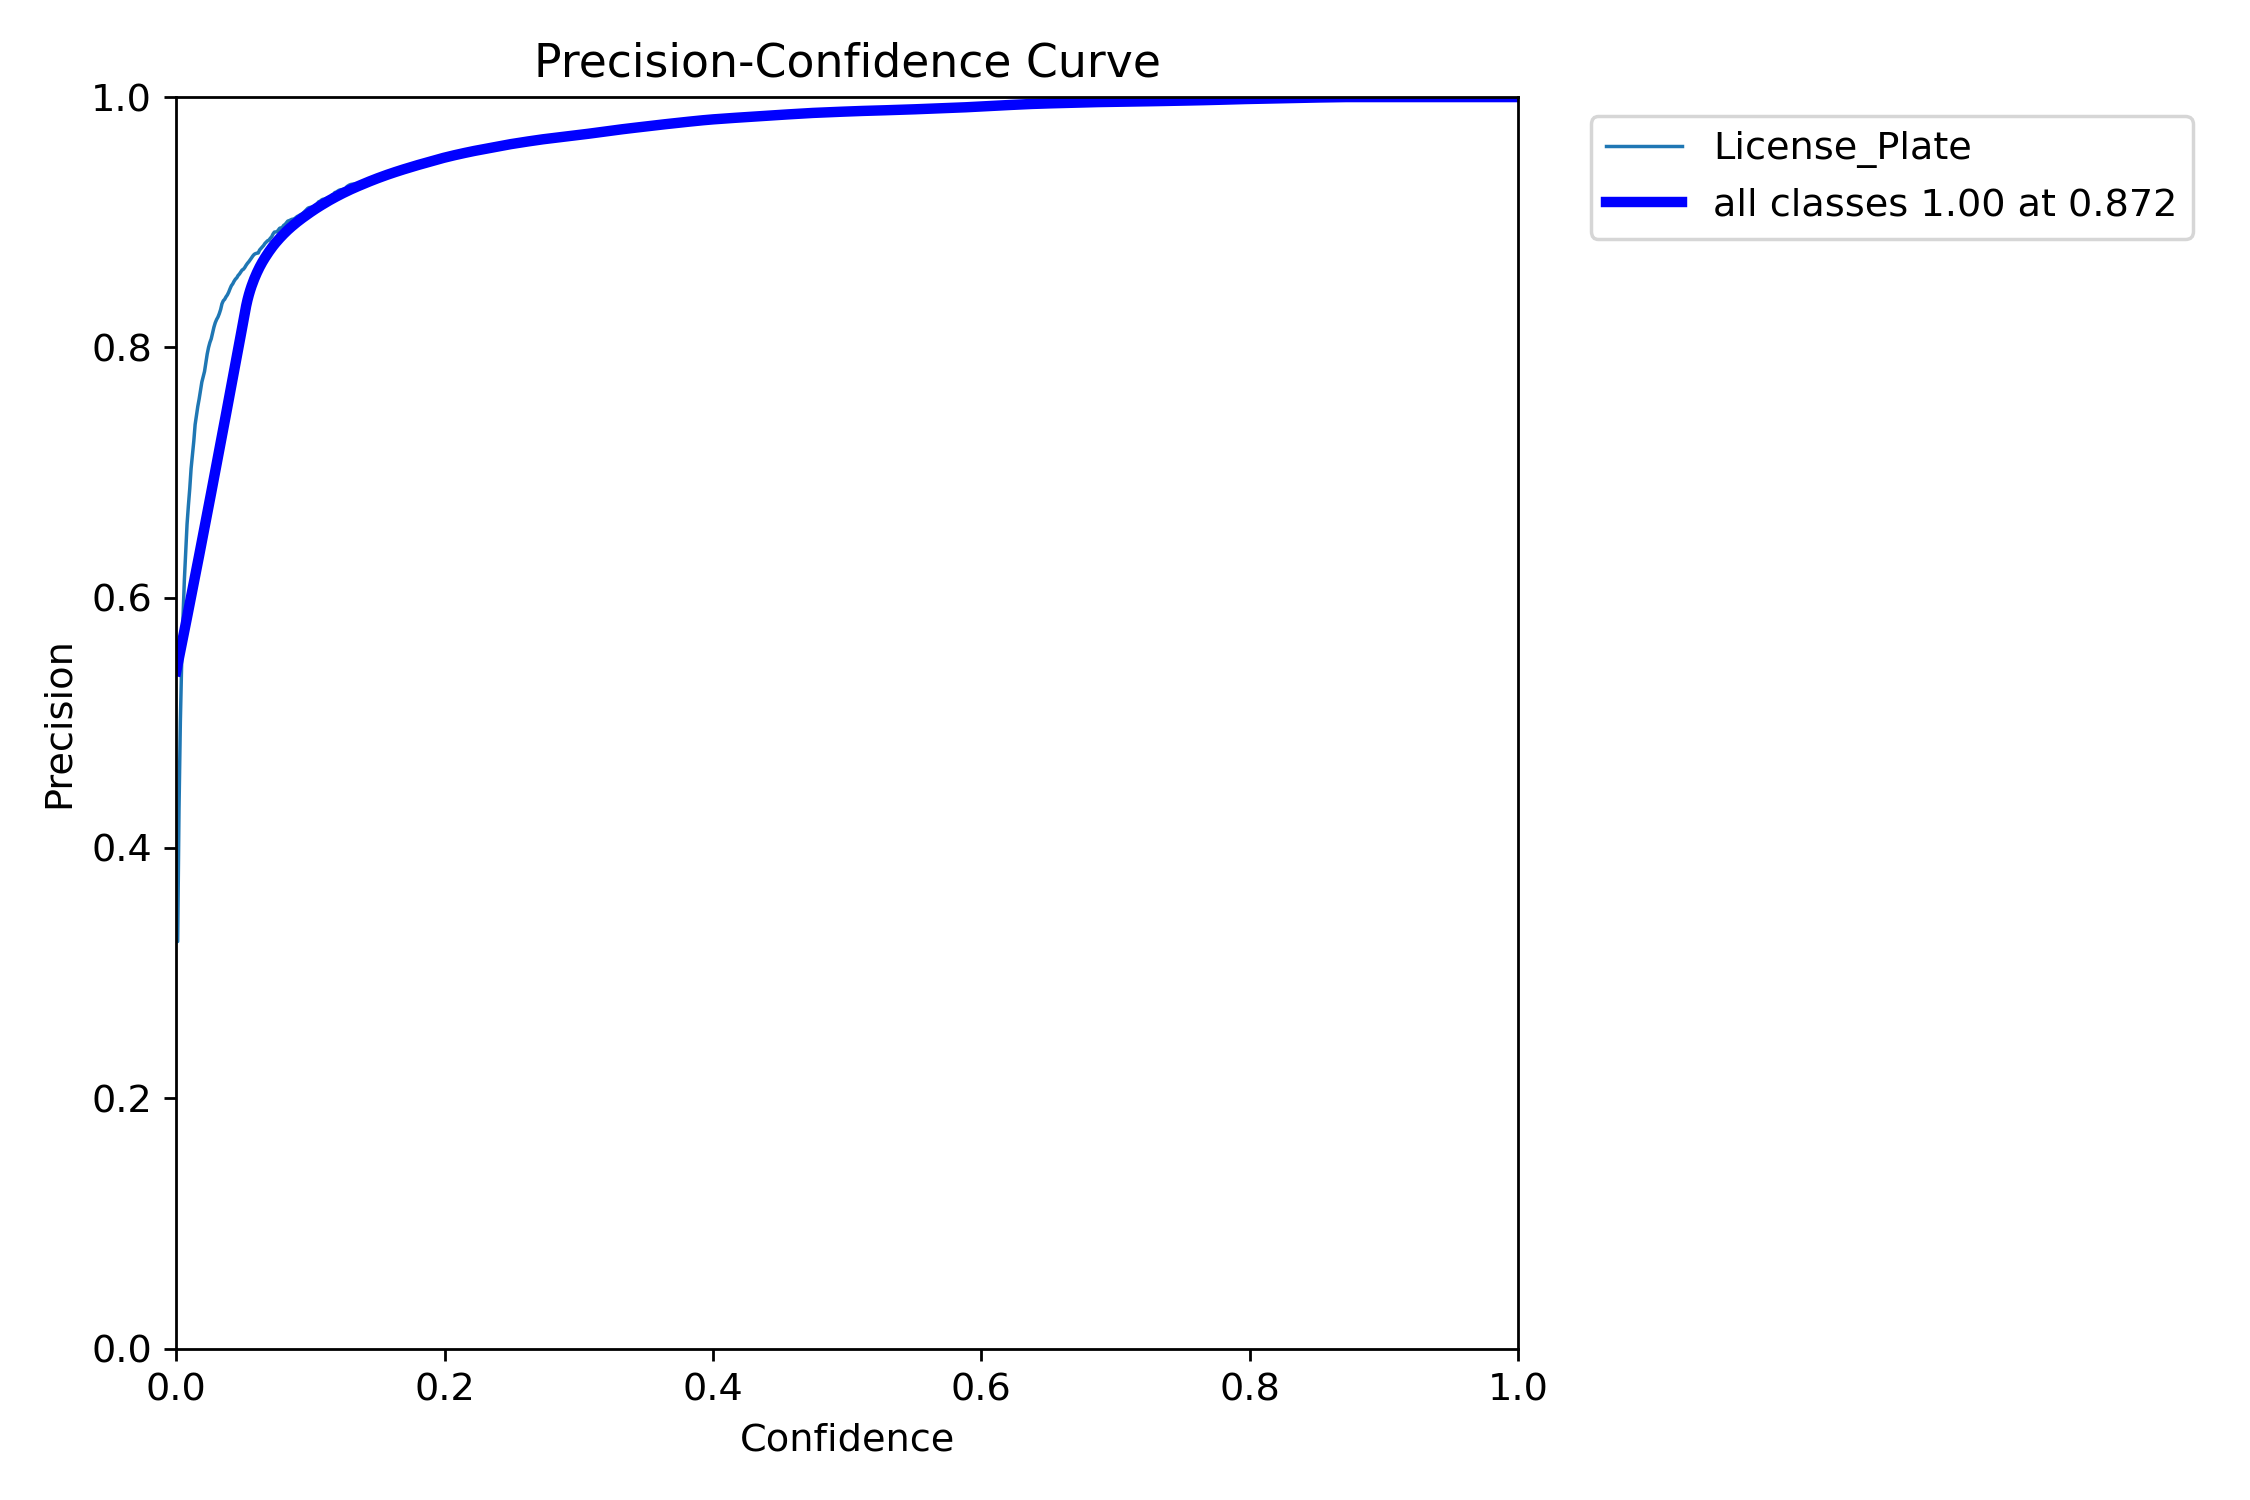


--- BoxR_curve.png ---


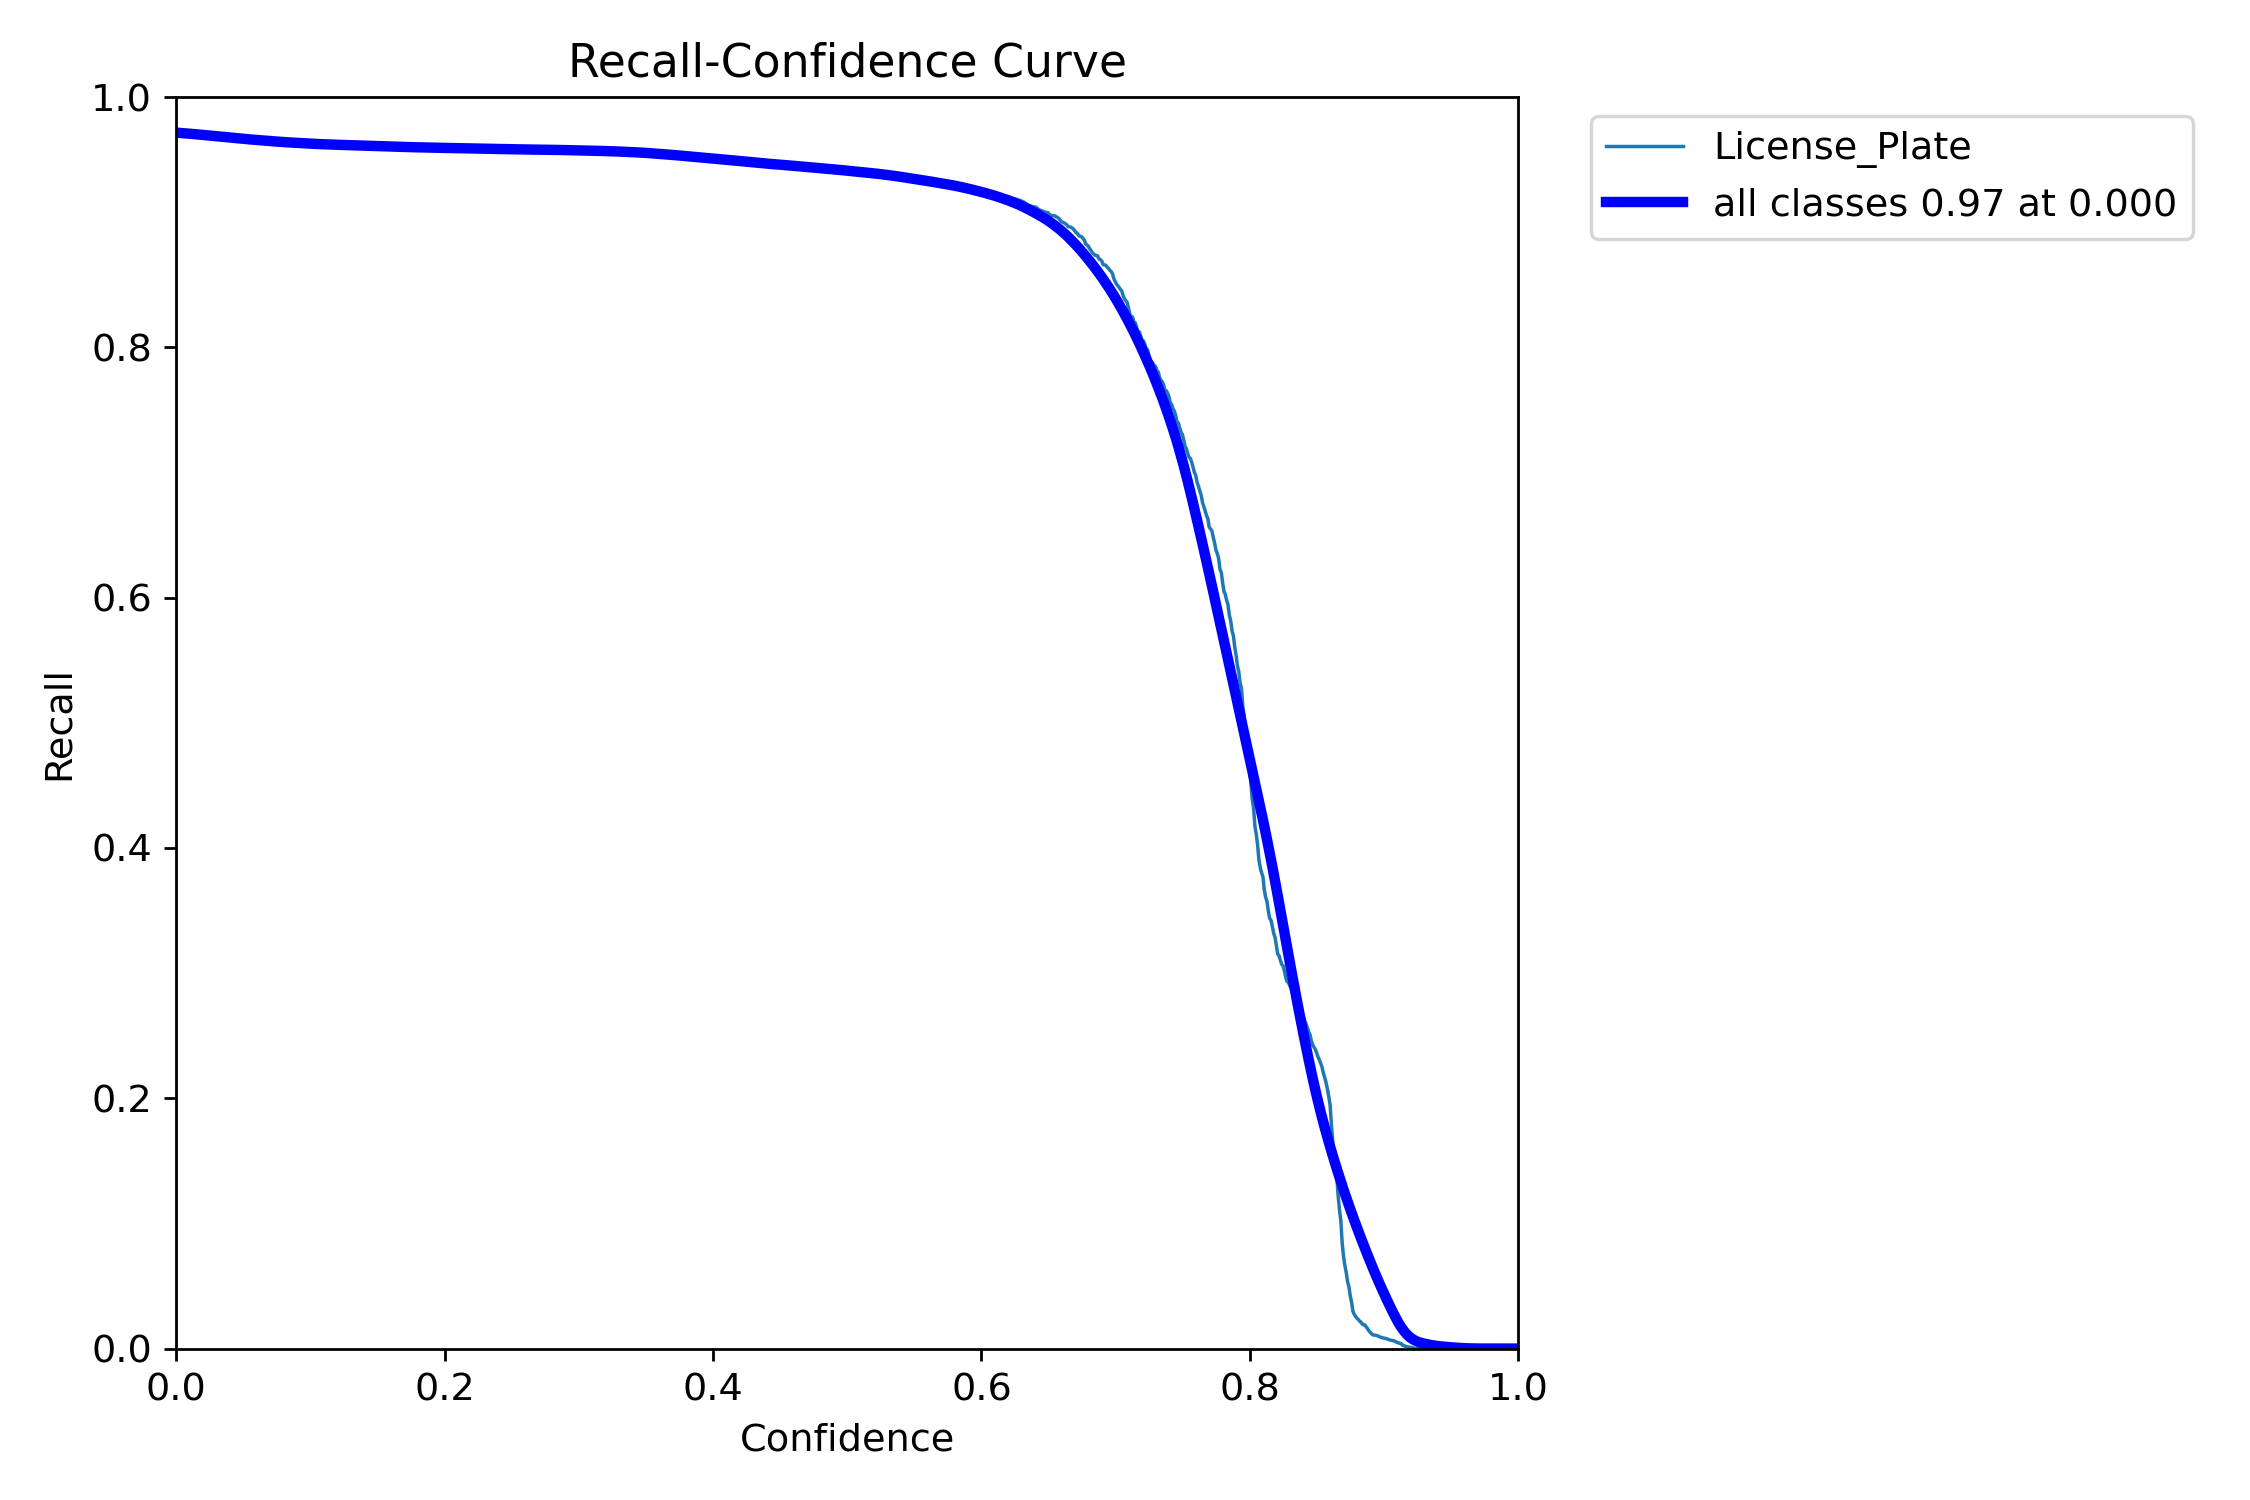

In [9]:
from IPython.display import Image as IPImage, display
import os

graphs = ["results.png", "confusion_matrix.png", "BoxPR_curve.png", "BoxF1_curve.png", "BoxP_curve.png", "BoxR_curve.png"]

for graph in graphs:
    path = f"/content/drive/MyDrive/plate_detector_runs/{graph}"
    if os.path.exists(path):
        print(f"\n--- {graph} ---")
        display(IPImage(path, width=800))
    else:
        print(f"{graph} not found")

In [17]:
import cv2
import easyocr
import glob
import os

reader = easyocr.Reader(['en'])

test_results = plate_model.predict(source="test_car.jpeg", conf=0.3, save=True, verbose=False)

img = cv2.imread("test_car.jpeg")

for r in test_results:
    for box in r.boxes.xyxy:
        x1, y1, x2, y2 = map(int, box)
        plate_crop = img[y1:y2, x1:x2]
        plate_big = cv2.resize(plate_crop, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
        ocr_results = reader.readtext(plate_big)
        print(f"Plate region detected: ({x1},{y1}) → ({x2},{y2})")
        for (_, text, conf) in ocr_results:
            clean = ''.join(c for c in text.upper() if c.isalnum())
            print(f"  OCR text: {clean} | Confidence: {conf:.2f}")

Results saved to /content/runs/detect/predict-2
Plate region detected: (162,486) → (217,510)
  OCR text: 60601 | Confidence: 0.44
Plate region detected: (599,498) → (645,517)


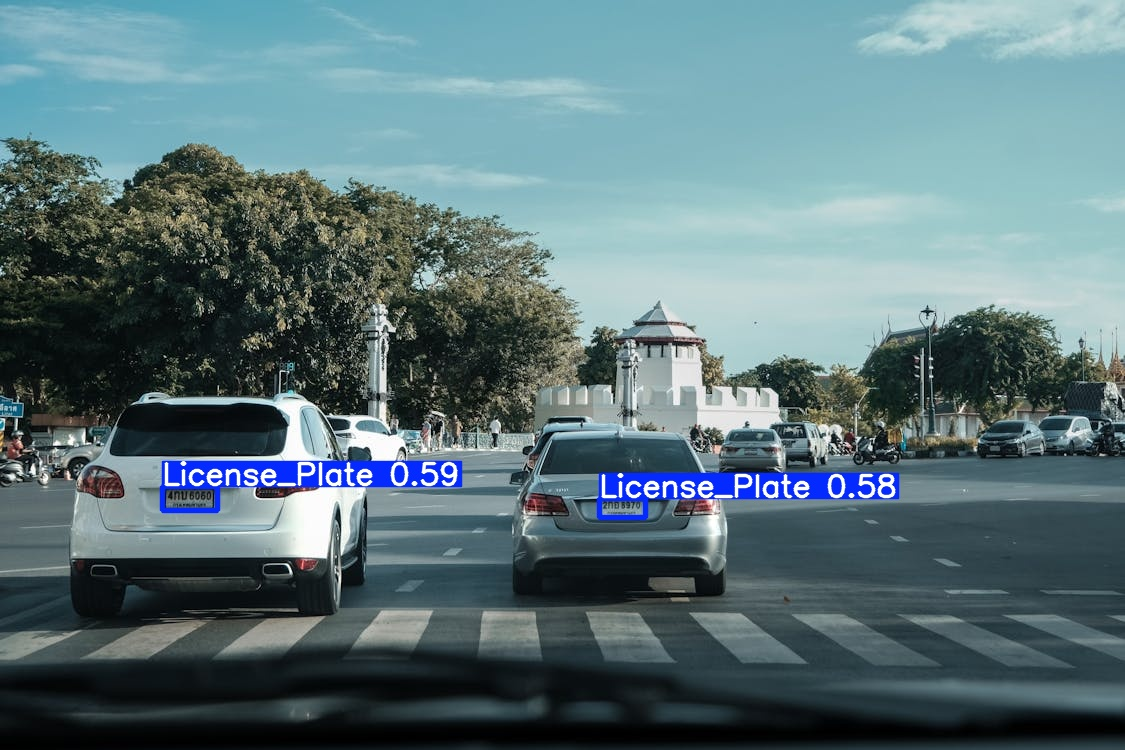

In [18]:
from IPython.display import Image as IPImage, display

display(IPImage("runs/detect/predict-2/test_car.jpg", width=600))